In [35]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

matches_df = pd.read_csv(r"C:\Users\PC\Downloads\Club-Football-Match-Data-2000-2025-main\Club-Football-Match-Data-2000-2025-main\data\Matches.csv")
elo_df = pd.read_csv(r"C:\Users\PC\Downloads\Club-Football-Match-Data-2000-2025-main\Club-Football-Match-Data-2000-2025-main\data\EloRatings.csv")
print("data files loaded successfully")

C:\Users\PC\AppData\Local\Temp\ipykernel_8776\2960472415.py:7: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  matches_df = pd.read_csv(r"C:\Users\PC\Downloads\Club-Football-Match-Data-2000-2025-main\Club-Football-Match-Data-2000-2025-main\data\Matches.csv")


data files loaded successfully


In [ ]:
ELO_BARCA =  1910.77
ELO_PSG = 1928.38
HOME_ADVANTAGE = 100
FORM_DIFF = 0 

In [ ]:
df = matches_df.dropna(subset=['HomeElo', 'AwayElo', 'FTResult', 'Form5Home', 'Form5Away']).copy()

# 1. Feature E
# ELO Difference : HomeElo - AwayElo
df['Elo_Diff'] = df['HomeElo'] - df['AwayElo']

# Form Difference: HomeTeam 5-match form - AwayTeam 5-match form
df['Form5_Diff'] = df['Form5Home'] - df['Form5Away']

# Target Variable: HomeWin ; 1 if 'H', 0 otherwise = 'D' or 'A'
df['HomeWin'] = (df['FTResult'] == 'H').astype(int)

print(f"Total historical matches used for training: {len(df)}")
print("Features (X): ['Elo_Diff', 'Form5_Diff']")
print("Target (y): 'HomeWin' (1 = Home Win, 0 = Draw/Away Win)")

Total historical matches used for training: 132004
Features (X): ['Elo_Diff', 'Form5_Diff']
Target (y): 'HomeWin' (1 = Home Win, 0 = Draw/Away Win)


In [3]:

intercept = -0.2097
elo_coeff = 0.0050
form_coeff = 0.0048

ELO_BARCA = 1945.43
ELO_PSG = 1974.94
HOME_ADVANTAGE = 100 
FORM_DIFF = 0 

draw_ratio_in_not_H = 0.4884
away_ratio_in_not_H = 0.5116


In [32]:
# Define features (X) and target (y)
X = df[['Elo_Diff', 'Form5_Diff']]
y = df['HomeWin']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Model Evaluation
accuracy = model.score(X_test, y_test)
print(f"Model Training Accuracy: {accuracy:.4f} (Accuracy on unseen test data)")

# Extract and display the learned coefficients
intercept = model.intercept_[0]
elo_coeff = model.coef_[0][0]
form_coeff = model.coef_[0][1]

print("\n--- Model Coefficients ---")
print(f"Intercept (c): {intercept:.4f}")
print(f"ELO Diff Coefficient (B_elo): {elo_coeff:.4f}")
print(f"Form Diff Coefficient (B_form): {form_coeff:.4f}")

Model Training Accuracy: 0.6282 (Accuracy on unseen test data)

--- Model Coefficients ---
Intercept (c): -0.2097
ELO Diff Coefficient (B_elo): 0.0050
Form Diff Coefficient (B_form): 0.0048


In [ ]:
not_home_win_df = df[df['FTResult'] != 'H']
total_not_home_wins = len(not_home_win_df)
total_draws = len(not_home_win_df[not_home_win_df['FTResult'] == 'D'])
total_away_wins = len(not_home_win_df[not_home_win_df['FTResult'] == 'A'])

draw_ratio_in_not_H = total_draws / total_not_home_wins
away_ratio_in_not_H = total_away_wins / total_not_home_wins

print("\n--- Historical Draw/Away Split ---")
print(f"Draws are {draw_ratio_in_not_H:.2%} of 'Not Home Win' outcomes.")

# --- Prediction Function ---
def predict_three_way_prob(home_elo, away_elo):
    """Calculates 3-way probability using the trained ML model and historical ratios."""
    
    elo_diff = (home_elo + HOME_ADVANTAGE) - away_elo

    z = intercept + elo_coeff * elo_diff + form_coeff * FORM_DIFF
    P_H = 1 / (1 + np.exp(-z))
    P_Not_H = 1 - P_H
    
    # 3. 3-Way Split
    P_D = P_Not_H * draw_ratio_in_not_H
    P_A = P_Not_H * away_ratio_in_not_H
    
    return P_H, P_D, P_A

# --- Run Predictions for both scenarios ---
print("\n--- ML Prediction Results for Barca vs. PSG ---")

# Predictions : Barcelona (Home) vs. Paris SG (Away)
P_H_A, P_D_A, P_A_A = predict_three_way_prob(ELO_BARCA, ELO_PSG)
print("\nPredictions: Barcelona (Home) vs Paris SG (Away)")
print(f"  P(Barcelona Win): {P_H_A * 100:.2f}%")
print(f"  P(Draw):          {P_D_A * 100:.2f}%")
print(f"  P(Paris SG Win):  {P_A_A * 100:.2f}%")



--- Historical Draw/Away Split ---
Draws are 48.84% of 'Not Home Win' outcomes.

--- ML Prediction Results for Barca vs. PSG ---

Predictions: Barcelona (Home) vs Paris SG (Away)
  P(Barcelona Win): 53.59%
  P(Draw):          22.67%
  P(Paris SG Win):  23.74%


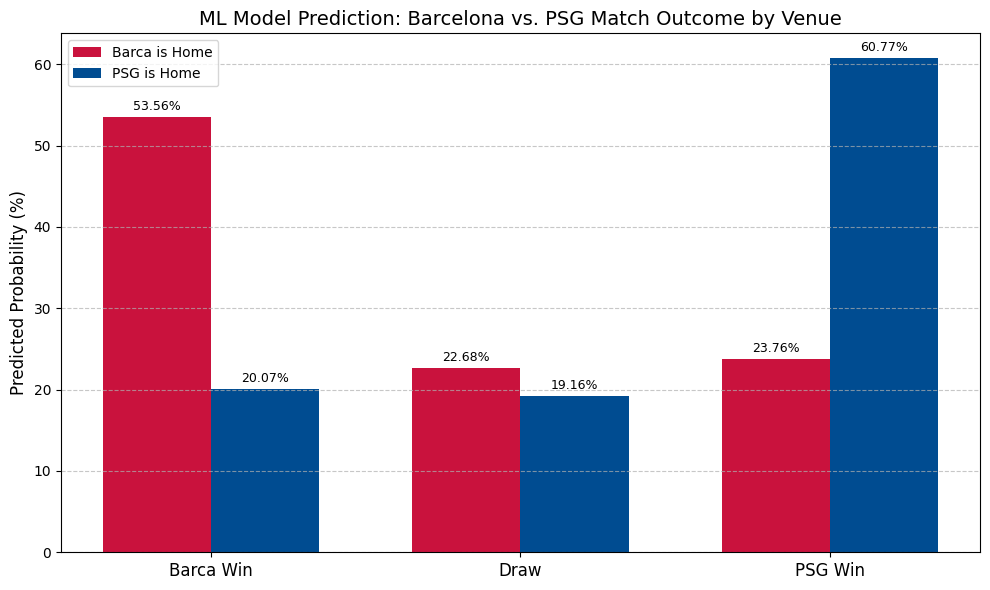

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


data = {
    'Outcome': ['Home Win', 'Draw', 'Away Win'],
    'Barca (Home)': [53.56, 22.68, 23.76],
    'PSG (Home)': [20.07, 19.16, 60.77] 
}


plot_df = pd.DataFrame({
    'Outcome': ['Barca Win', 'Draw', 'PSG Win'],
    'Barca (Home)': [53.56, 22.68, 23.76],
    'PSG (Home)': [20.07, 19.16, 60.77]
})


labels = plot_df['Outcome']
barca_home_probs = plot_df['Barca (Home)']

x = np.arange(len(labels))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, barca_home_probs, width, label='Barca is Home', color='#C9123D') 
rects2 = ax.bar(x + width/2, psg_home_probs, width, label='PSG is Home', color='#004C91')    

ax.set_ylabel('Predicted Probability (%)', fontsize=12)
ax.set_title('ML Model Prediction: Barcelona vs. PSG Match Outcome by Venue', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=10)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()